In [ ]:
from google.colab import files
uploaded = files.upload()

Saving go_emotions_dataset.csv to go_emotions_dataset.csv


In [ ]:
import pandas as pd
df = pd.read_csv("go_emotions_dataset.csv")
df.head()

,id,text,example_very_unclear,admiration,amusement,anger,annoyance,approval,caring,confusion,...,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
0,eew5j0j,That game hurt.,False,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,eemcysk,>sexuality shouldn’t be a grouping category I...,True,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,ed2mah1,"You do right, if you don't care then fuck 'em!",False,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,eeibobj,Man I love reddit.,False,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
4,eda6yn6,"[NAME] was nowhere near them, he was by the Fa...",False,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [ ]:
emotion_cols = df.columns[3:]
emotion_cols

Index(['admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring',
       'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval',
       'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief',
       'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization',
       'relief', 'remorse', 'sadness', 'surprise', 'neutral'],
      dtype='object')

In [ ]:
df['label'] = df[emotion_cols].idxmax(axis=1)

df[['text', 'label']].head()

,text,label
0,That game hurt.,sadness
1,>sexuality shouldn’t be a grouping category I...,admiration
2,"You do right, if you don't care then fuck 'em!",neutral
3,Man I love reddit.,love
4,"[NAME] was nowhere near them, he was by the Fa...",neutral


In [ ]:
selected = ['joy', 'sadness', 'anger', 'fear', 'love', 'surprise']

df = df[df['label'].isin(selected)]

df['label'].value_counts()

,count
label,
anger,7956
love,5310
joy,5120
sadness,3863
surprise,3472
fear,2514


In [ ]:
df = df[['text', 'label']]

df.head()

,text,label
0,That game hurt.,sadness
3,Man I love reddit.,love
37,"I just came home, what the fuck is this lineup...",love
43,By far the coolest thing I've seen on this thr...,joy
49,Sending love and strength vibes <3,joy


In [ ]:
label_map = {label: i for i, label in enumerate(df['label'].unique())}

df['label'] = df['label'].map(label_map)

label_map

{'sadness': 0, 'love': 1, 'joy': 2, 'surprise': 3, 'anger': 4, 'fear': 5}

In [ ]:
from sklearn.model_selection import train_test_split

train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df['text'], df['label'], test_size=0.3, random_state=42
)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts, temp_labels, test_size=0.5, random_state=42
)

len(train_texts), len(val_texts), len(test_texts)

(19764, 4235, 4236)

In [ ]:
!pip install transformers

In [ ]:
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
train_encodings = tokenizer(list(train_texts), truncation=True, padding=True, max_length=128)
val_encodings = tokenizer(list(val_texts), truncation=True, padding=True, max_length=128)
test_encodings = tokenizer(list(test_texts), truncation=True, padding=True, max_length=128)

In [ ]:
type(train_encodings)

transformers.tokenization_utils_base.BatchEncoding

In [ ]:
print(list(train_encodings.keys()))

['input_ids', 'token_type_ids', 'attention_mask']


In [ ]:
import torch

class Dataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = list(labels)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

In [ ]:
train_dataset = Dataset(train_encodings, train_labels)
val_dataset = Dataset(val_encodings, val_labels)
test_dataset = Dataset(test_encodings, test_labels)

In [ ]:
len(train_dataset), len(val_dataset), len(test_dataset)

(19764, 4235, 4236)

In [ ]:
from transformers import BertForSequenceClassification

model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=6
)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    logging_dir='./logs'
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [ ]:
!pip install scikit-learn

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(pred):
    labels = pred.label_ids
    preds = np.argmax(pred.predictions, axis=1)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average='weighted')
    return {'accuracy': acc, 'f1': f1}

In [ ]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

In [ ]:
import torch
torch.cuda.is_available()

True

In [ ]:
trainer.train()

Step,Training Loss
500,1.030880
1000,0.837951
1500,0.799807
2000,0.789680
2500,0.747462
3000,0.589340
3500,0.573258
4000,0.607781
4500,0.544319
5000,0.550223


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=7413, training_loss=0.6074229700594606, metrics={'train_runtime': 1861.8085, 'train_samples_per_second': 31.846, 'train_steps_per_second': 3.982, 'total_flos': 2498588202626784.0, 'train_loss': 0.6074229700594606, 'epoch': 3.0})

In [ ]:
trainer.evaluate(test_dataset)

{'eval_loss': 0.9156861901283264,
 'eval_accuracy': 0.7707743153918791,
 'eval_f1': 0.7697887457084475,
 'eval_runtime': 14.3603,
 'eval_samples_per_second': 294.98,
 'eval_steps_per_second': 36.907,
 'epoch': 3.0}

In [ ]:
predictions = trainer.predict(test_dataset)

preds = predictions.predictions.argmax(axis=1)
true = predictions.label_ids

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(true, preds))

              precision    recall  f1-score   support

           0       0.74      0.67      0.70       582
           1       0.82      0.86      0.84       820
           2       0.81      0.72      0.76       816
           3       0.71      0.71      0.71       498
           4       0.78      0.84      0.81      1174
           5       0.66      0.70      0.68       346

    accuracy                           0.77      4236
   macro avg       0.75      0.75      0.75      4236
weighted avg       0.77      0.77      0.77      4236



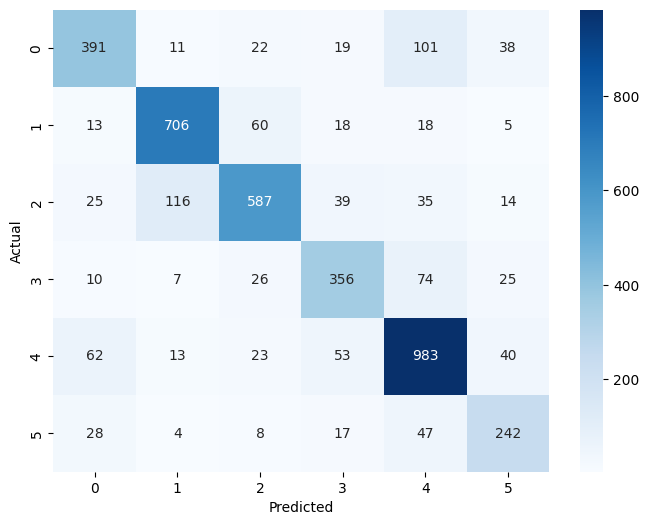

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(true, preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

to save the model

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

trainer.save_model("/content/drive/MyDrive/emotion_model")
tokenizer.save_pretrained("/content/drive/MyDrive/emotion_model")

Mounted at /content/drive


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/drive/MyDrive/emotion_model/tokenizer_config.json',
 '/content/drive/MyDrive/emotion_model/tokenizer.json')

optional backup to save the model in zip

In [ ]:
!zip -r emotion_model.zip /content/drive/MyDrive/emotion_model

  adding: content/drive/MyDrive/emotion_model/ (stored 0%)
  adding: content/drive/MyDrive/emotion_model/config.json (deflated 56%)
  adding: content/drive/MyDrive/emotion_model/model.safetensors (deflated 7%)
  adding: content/drive/MyDrive/emotion_model/training_args.bin (deflated 53%)
  adding: content/drive/MyDrive/emotion_model/tokenizer_config.json (deflated 42%)
  adding: content/drive/MyDrive/emotion_model/tokenizer.json (deflated 71%)


In [ ]:
from google.colab import files
files.download("emotion_model.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## to use the model again (from drive)




In [1]:
from google.colab import drive
drive.mount('/content/drive')

from transformers import AutoModelForSequenceClassification, AutoTokenizer, pipeline

model_path = "/content/drive/MyDrive/emotion_model"

model = AutoModelForSequenceClassification.from_pretrained(model_path)
tokenizer = AutoTokenizer.from_pretrained(model_path)

classifier = pipeline("text-classification", model=model, tokenizer=tokenizer)

print("Model loaded successfully!")

Mounted at /content/drive


Loading weights:   0%|          | 0/201 [00:01<?, ?it/s]

Model loaded successfully!


to use the model again (from my downloads, zip)

In [ ]:
from google.colab import files
uploaded = files.upload()
#Select emotion_model.zip

In [ ]:
!unzip emotion_model.zip

In [ ]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer, pipeline

model = AutoModelForSequenceClassification.from_pretrained("emotion_model")
tokenizer = AutoTokenizer.from_pretrained("emotion_model")

classifier = pipeline("text-classification", model=model, tokenizer=tokenizer)

print("Model loaded from ZIP successfully!")

In [ ]:
import nbformat

# Open the notebook file properly
with open("Assil_Project_DL_Final.ipynb", "r", encoding="utf-8") as f:
    nb = nbformat.read(f, as_version=4)

# Remove problematic widget metadata safely
if "widgets" in nb["metadata"]:
    nb["metadata"].pop("widgets")

# Also clean each cell (important)
for cell in nb["cells"]:
    if "metadata" in cell and "widgets" in cell["metadata"]:
        cell["metadata"].pop("widgets")

# Save cleaned notebook
with open("Assil_Project_DL_CLEAN.ipynb", "w", encoding="utf-8") as f:
    nbformat.write(nb, f)